# Checking model conditions using graphs

---

#### Summary videos

- [Checking multiple regression diagnostics using graphs](https://youtu.be/3KSUeYMKt5A?si=_HSmuP88FgHaaGmP) (3 minutes)

---

Multiple regression models usually depend on the following four conditions.

- **Nearly normal residuals.** The residuals for the model should be nearly normal, though this is less important for large datasets.
- **Constant residual variability.** The variability in the residuals should be nearly constant.
- **Independence.** The residuals should be independent.
- **Linearity.** Each predictor should be linearly related to the response variable when the other predictors are held constant.

As we've seen previously, verifying conditions like this can be difficult or subjective. Consider the following quote from page 362 of the textbook.

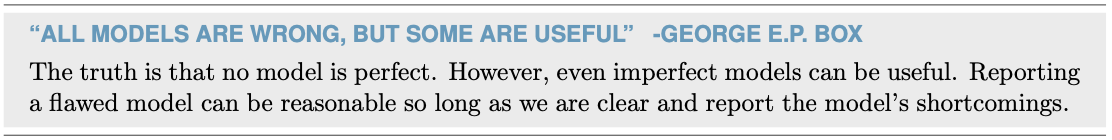

## Diagnostic plots

We can use **diagnostic plots** to investigate the conditions above. We'll use our model from the `loans` data.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scipy.stats as stats
import pandas as pd
import statsmodels.api as sm
from plotnine import *

loans = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/main/loans_full_schema.csv')

loans['bankruptcy'] = loans['public_record_bankrupt'].apply(lambda x: 1 if x > 0 else 0)

def least_squares_regression(data, response_variable, predictor_variable):
  dataframe = data
  formula_string = response_variable + " ~ " + predictor_variable
  model = sm.formula.ols(formula = formula_string, data = dataframe)
  model_fitted = model.fit()

  print(model_fitted.summary())
  return model_fitted

model = least_squares_regression(loans,
                         'interest_rate',
                         'verified_income + debt_to_income + bankruptcy + term + months_since_last_credit_inquiry')

print(model)

### Nearly normal residuals

Let's first compute the residuals of the model.

In [ ]:
X = loans[['verified_income', 'debt_to_income', 'bankruptcy', 'term', 'months_since_last_credit_inquiry']]

Y = loans['interest_rate']

Y_hat = model.predict(X)

residuals = Y - Y_hat
df = residuals.to_frame('residuals')
loans['residuals'] = df['residuals']
loans['absolute_residuals'] = abs(df['residuals'])
loans['squared_residuals'] = df['residuals'] ** 2
loans['ovserved_values'] = Y
loans['predicted_values'] = Y_hat

Now let's look at a histogram.

In [ ]:
(
    ggplot(loans) +
    aes(x = 'residuals') +
    geom_histogram(bins = 20)
)

We'd like the residuals to be nearly normal. Is that the case here? Let's consider a Q-Q plot, as well.

In [ ]:
def qq_plot(dataframe, variable, title):
  plot = (
      ggplot(dataframe) +
      aes(sample = variable) +
      stat_qq() +
      stat_qq_line() +
      labs(title = title)
  )
  return plot

In [ ]:
qq_plot(loans, 'residuals', 'Q-Q plot of residuals')

It appears that the residuals are not nearly normal. However,

> The normal residuals condition is commonly relaxed in many applications as long as there are not any particularly extreme outliers.

#### Question

Are there any particularly extreme outliers on the histogram?

### Constant residual variability

To examine the constant variability on the residuals, we can plot the magnitude of the residuals against there predicted value.

In [ ]:
(
    ggplot(loans) +
    aes(x = 'predicted_values', y = 'absolute_residuals') +
    geom_point(alpha = 0.2) +
    geom_smooth(se = False, color = 'red')
)

Ideally, if the variability on the residuals is constant, we should see no evident pattern in this plot --- this would mean that the size of the residuals does not depend on the predicted values.

#### Question

The red curve represents the trend in the plot. Describe the trend and interpret what that might mean in regard to the variability on the residuals.

> Again, no model is perfect --- but, even an imperfect model can be useful provided that we are aware of its limitations.
>
> As long as the conditions are not *egregiously* violated, it is typically reasonable to proceed --- just be sure to make note of concerns regarding the model's performance or accuracy that come up during diagnostics.

### Independence of residuals

If the data were collected sequentially, it would be important to determine whether the residuals are independent. In this case, we could plot the residuals in the order of their collection. Recall, we removed the `issue_month` variable from our model, so this is not expected to be important.

In [ ]:
plot_data = pd.DataFrame()
plot_data['issue_month'] = loans['issue_month']
plot_data['residuals'] = loans['residuals']

(
    ggplot(plot_data) +
    aes(x = 'issue_month', y = 'residuals') +
    geom_jitter(alpha = 0.2)
)

There is no evident pattern in the plot, so we expect the residuals are independent. Otherwise, we would have to resort to using a **time series** model.

### Linearity

We can now investigate the residuals against each of the predictor variables. We are looking for any notable variability or patterns in the residuals from the plots that would indicate a lack of linearity.

In [ ]:
# verified_income
(
    ggplot(loans) +
    aes(x = 'verified_income', y = 'residuals') +
    geom_boxplot()
)

In [ ]:
# debt_to_income
(
    ggplot(loans) +
    aes(x = 'debt_to_income', y = 'residuals') +
    geom_point(alpha = 0.2) +
    geom_smooth(se = False, color = 'red')
)

In [ ]:
# bankruptcy
(
    ggplot(loans.replace([0,1], ["0", "1"])) +
    aes(x = 'bankruptcy', y = 'residuals') +
    geom_boxplot()
)

In [ ]:
# term
(
    ggplot(loans.replace([36, 60], ["36", "60"])) +
    aes(x = 'term', y = 'residuals') +
    geom_boxplot()
)

In [ ]:
# months_since_last_credit_inquiry
(
    ggplot(loans) +
    aes(x = 'months_since_last_credit_inquiry', y = 'residuals') +
    geom_jitter(alpha = 0.2) +
    geom_smooth(se = False, color = 'red')
)

## Improving the fit

Something that stands out in these plots is the strong right-skew of the `debt_to_income` variable.

In [ ]:
(
    ggplot(loans) +
    aes(x = 'debt_to_income') +
    geom_histogram()
)

We can create a new varible that truncates `debt_to_income` at 50 to cut off the points in the tail of the distribution and refit the model.

In [ ]:
loans['debt_to_income_50'] = loans['debt_to_income'].apply(lambda x: 50 if x > 50 else x)

least_squares_regression(loans,
                         'interest_rate',
                         'verified_income + debt_to_income_50 + bankruptcy + term + months_since_last_credit_inquiry')

### Questions

- Which model seems to be better?

- How did the coefficient for `debt_to_income` change when the variable was replaced with `debt_to_income_50`? What might that tell you about how the tail values from `debt_to_income`'s influence on the model?

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.